<a href="https://colab.research.google.com/github/sathu0622/DL_Assigment/blob/feature%2Frajendram/CNN(Augmentation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**
This section focuses on building a Convolutional Neural Network (CNN) model enhanced with **data augmentation** techniques to improve generalization and reduce overfitting. The Fashion MNIST dataset is used again, which contains grayscale images of clothing items from ten categories.  
By applying transformations such as rotations, zooming, and shifting, the model is exposed to a wider variety of training examples without collecting new data. This helps the network learn more robust visual features.


# **Import Required Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# **Load and Preprocess the Dataset**

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Applying Data Augmentation**

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

# **Building the CNN Model**

In [ ]:
model4 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compiling the Model**

In [ ]:
model4.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# **Training the Model**

In [ ]:
history4 = model4.fit(datagen.flow(x_train, y_train, batch_size=64),
                      epochs=15,
                      validation_data=(x_test, y_test))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.5856 - loss: 1.1207 - val_accuracy: 0.7830 - val_loss: 0.5594
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.7476 - loss: 0.6723 - val_accuracy: 0.8072 - val_loss: 0.4877
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.7763 - loss: 0.5990 - val_accuracy: 0.8254 - val_loss: 0.4400
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 83ms/step - accuracy: 0.7925 - loss: 0.5587 - val_accuracy: 0.8541 - val_loss: 0.3946
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.8083 - loss: 0.5165 - val_accuracy: 0.8698 - val_loss: 0.3669
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.8187 - loss: 0.4977 - val_accuracy: 0.8657 - val_loss: 0.3607
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - accuracy: 0.8248 - loss: 0.4708 - val_accuracy: 0.8704 - val_loss: 0.3508
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 80ms/step - accuracy: 0.8289 - loss: 0.4647 - val_accurac

#**Evaluating the Model**

In [ ]:
test_loss, test_acc = model4.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy (CNN + Augmentation): {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8794 - loss: 0.3370

Final Test Accuracy (CNN + Augmentation): 0.8807


# **Visualizing Training Progress**

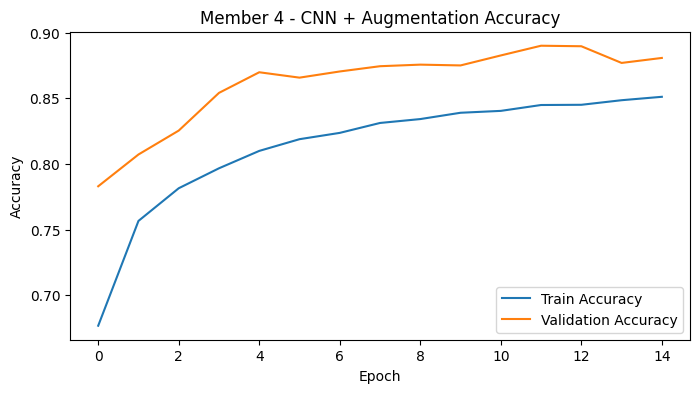

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history4.history['accuracy'], label='Train Accuracy')
plt.plot(history4.history['val_accuracy'], label='Validation Accuracy')
plt.title("Member 4 - CNN + Augmentation Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()